# CMEMS DUACS Sea Level Analysis — Reproducible Notebook

**Product:** SEALEVEL_GLO_PHY_L4_MY_008_047 (0.125° daily)
**File naming:** `dt_global_allsat_phy_l4_YYYYMMDD_YYYYMMDD.nc` (flat directory)

This notebook produces:
1. **Monthly mean maps** — 3×4 panel of monthly mean per year in `YEARS`
2. **Monthly anomaly maps** — monthly mean minus annual mean, 3×4 panel
3. **Daily maps** — panel of daily maps for a chosen month and day range

---

### How to use

1. **Edit only the Configuration cell** (Section 2) — set paths, years, region, and plot options
2. Run → **Restart & Run All**
3. Output PNGs are saved to `OUTPUT_DIR`

> **Requirements:** `xarray`, `numpy`, `matplotlib`, `cartopy`

---
## Section 1 — Imports

In [36]:
import os
import re
import glob
import warnings
from datetime import datetime
from math import ceil
from calendar import month_name

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries loaded.")

Libraries loaded.


---
## Section 2 — Configuration

> **Edit ONLY this cell.** All paths, years, region, and plot settings live here.
> After editing, run **Restart & Run All** to regenerate all outputs.

In [37]:
# =============================================================================
# CONFIGURATION — Edit ONLY this cell
# =============================================================================

# ---- Paths ------------------------------------------------------------------
# Folder containing the daily *.nc files downloaded from CMEMS
DATA_DIR  = r"C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024"

# Folder where output PNGs are saved (created automatically if absent)
OUTPUT_DIR = r"C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs"

# ---- Years ------------------------------------------------------------------
# List of integer years to process.  The notebook loops over each year and
# produces one output file per plot type per year.
# Example for multiple years:  YEARS = [2022, 2023, 2024]
YEARS = [2024]

# ---- Variable ---------------------------------------------------------------
# CMEMS variable to analyse.  Common choices:
#   'sla'   — Sea Level Anomaly (m)
#   'adt'   — Absolute Dynamic Topography (m)
#   'ugosa' — Geostrophic velocity anomaly, U-component (m/s)
#   'vgosa' — Geostrophic velocity anomaly, V-component (m/s)
VAR_NAME = "sla"

# ---- Region of interest -----------------------------------------------------
# [lon_min, lon_max, lat_min, lat_max] in decimal degrees.
# Positive = East / North,  Negative = West / South.
# Set to None to plot the full global domain.
#
# Common presets:
#   Indian Ocean  : [40, 100, -10,  30]
#   Bay of Bengal : [80, 100,   5,  25]
#   Arabian Sea   : [55,  78,   5,  25]
#   Global        : None
REGION = [80, 100, 5, 25]

# ---- Plot selection ---------------------------------------------------------
DO_MONTHLY = True   # 3x4 panel of monthly mean maps   (one figure per year)
DO_ANOMALY = True   # 3x4 panel of monthly anomaly maps (one figure per year)
DO_DAILY   = True   # Panel of daily maps for a chosen month (one figure per year)

# ---- Daily plot settings (only used when DO_DAILY = True) -------------------
DAILY_MONTH     = 1    # Month to plot  (1 = January ... 12 = December)
DAILY_DAY_START = 1    # First day of the range (inclusive)
DAILY_DAY_END   = 7    # Last day  of the range (inclusive)
DAYS_PER_ROW    = 5    # Number of subplot columns in the daily panel

# ---- Colormap & colour limits -----------------------------------------------
# Tip: Run the Dataset Exploration cell (Section 4) first — it prints the
# SLA range for your region.  Then set SLA_VMIN / SLA_VMAX here and
# run Restart & Run All.
SLA_CMAP = "RdBu_r"   # any matplotlib colormap
SLA_VMIN = None        # lower colorbar limit in metres  (None = auto 2nd pctl)
SLA_VMAX = None        # upper colorbar limit in metres  (None = auto 98th pctl)

# ---- Derived (do not edit) --------------------------------------------------
if REGION is not None:
    REGION_LABEL = f"[{REGION[0]}\u00b0\u2013{REGION[1]}\u00b0E, {REGION[2]}\u00b0\u2013{REGION[3]}\u00b0N]"
else:
    REGION_LABEL = "Global"

print("Configuration loaded.")
print(f"  Data dir    : {DATA_DIR}")
print(f"  Output dir  : {OUTPUT_DIR}")
print(f"  Years       : {YEARS}")
print(f"  Variable    : {VAR_NAME}")
print(f"  Region      : {REGION_LABEL}")
print(f"  Monthly     : {DO_MONTHLY}")
print(f"  Anomaly     : {DO_ANOMALY}")
print(f"  Daily       : {DO_DAILY}")
if DO_DAILY:
    print(f"  Daily month : {month_name[DAILY_MONTH]}  "
          f"days {DAILY_DAY_START}\u2013{DAILY_DAY_END}")

Configuration loaded.
  Data dir    : C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024
  Output dir  : C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs
  Years       : [2024]
  Variable    : sla
  Region      : [80°–100°E, 5°–25°N]
  Monthly     : True
  Anomaly     : True
  Daily       : True
  Daily month : January  days 1–7


---
## Section 3 — Helper Functions

Run this section once to register all helper functions.
Each function is fully documented — hover over a call in VS Code or JupyterLab for the complete docstring.

In [38]:
def extract_date_from_cmems_filename(filepath):
    """
    Parse a Python ``datetime`` from a CMEMS DUACS daily NetCDF filename.

    CMEMS DUACS L4 daily files follow the naming convention::

        dt_global_allsat_phy_l4_YYYYMMDD_YYYYMMDD.nc

    The first ``YYYYMMDD`` token (immediately after ``_l4_``) is the **data
    date**; the second is the processing / reprocessing date.  Only the
    first token is extracted and converted to a ``datetime`` object.

    Parameters
    ----------
    filepath : str
        Absolute or relative path to a CMEMS NetCDF file.  Only the
        basename is inspected; the directory portion is ignored.

    Returns
    -------
    datetime.datetime
        Midnight on the data date (hour, minute, second all zero).

    Raises
    ------
    ValueError
        If the filename does not contain an ``_l4_YYYYMMDD_`` token.

    Examples
    --------
    >>> extract_date_from_cmems_filename(
    ...     "dt_global_allsat_phy_l4_20240615_20250429.nc")
    datetime.datetime(2024, 6, 15, 0, 0)
    """
    filename = os.path.basename(filepath)
    match = re.search(r'_l4_(\d{8})_', filename)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    raise ValueError(f"Cannot parse date from filename: {filename}")

In [39]:
def scan_cmems_dataset(data_dir):
    """
    Discover all NetCDF files in *data_dir* and report which years are present.

    Performs a non-recursive glob for ``*.nc`` files directly inside
    *data_dir*, then parses the calendar year from each filename via
    ``extract_date_from_cmems_filename``.  Files whose names do not match
    the expected pattern are silently skipped (they still appear in
    *all_files* but do not contribute to *years*).

    Parameters
    ----------
    data_dir : str
        Directory containing the flat CMEMS daily ``.nc`` files.

    Returns
    -------
    all_files : list of str
        Chronologically sorted list of absolute paths to every ``.nc`` file.
    years : set of int
        Set of calendar years inferred from the filenames.
        Use ``sorted(years)`` for an ordered list.

    Examples
    --------
    >>> files, years = scan_cmems_dataset(DATA_DIR)
    >>> print(sorted(years))
    [2024]
    >>> print(len(files))
    366
    """
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

    years = set()
    for f in all_files:
        try:
            years.add(extract_date_from_cmems_filename(f).year)
        except ValueError:
            pass

    return all_files, years

In [40]:
def load_cmems_var(filepath, var_name, region=None):
    """
    Load a single variable from a CMEMS daily NetCDF file as a 2-D DataArray.

    Execution steps
    ---------------
    1. **Open** the file with ``xr.open_dataset`` (lazy / memory-mapped).
    2. **Select** *var_name* and remove the singleton ``time`` dimension
       with ``isel(time=0)`` so the result is 2-D (latitude x longitude).
    3. **Subset** to *region* with label-based indexing (``DataArray.sel``).
       Handles both ascending and descending latitude axes automatically.
       Skipped when *region* is ``None``.
    4. **Load** into RAM and close the file handle.

    CMEMS variables are already in SI units (metres for SLA / ADT,
    m s\u207b\u00b9 for velocity anomalies) — no unit conversion is applied.

    Parameters
    ----------
    filepath : str
        Path to a single CMEMS daily NetCDF file.
    var_name : str
        Variable to extract (e.g. ``"sla"``, ``"adt"``, ``"ugosa"``).
    region : list of float or None, optional
        ``[lon_min, lon_max, lat_min, lat_max]`` bounding box in decimal
        degrees.  ``None`` loads the full global domain.

    Returns
    -------
    xr.DataArray
        2-D (latitude x longitude) array.  Retains ``latitude`` and
        ``longitude`` coordinate arrays for direct use in ``make_sla_map``.

    Raises
    ------
    KeyError
        If *var_name* is not a variable in the file.

    Examples
    --------
    >>> da = load_cmems_var(
    ...     "dt_global_allsat_phy_l4_20240601_20250429.nc",
    ...     "sla", region=[80, 100, 5, 25])
    >>> print(f"{float(da.min()):.3f} m  to  {float(da.max()):.3f} m")
    -0.148 m  to  0.617 m
    """
    ds = xr.open_dataset(filepath)
    da = ds[var_name].isel(time=0)   # daily file has one time step

    if region is not None:
        lon_min, lon_max, lat_min, lat_max = region
        lats = da.latitude.values
        lat_slice = (slice(lat_max, lat_min)
                     if lats[0] > lats[-1]
                     else slice(lat_min, lat_max))
        da = da.sel(latitude=lat_slice,
                    longitude=slice(lon_min, lon_max))

    da = da.load()
    ds.close()
    return da

In [41]:
def make_sla_map(ax, sla_data, title, vmin, vmax, cmap, show_cbar=False):
    """
    Render a filled sea-level map on a Cartopy ``PlateCarree`` axes object.

    Draws the field with ``pcolormesh`` and overlays standard map features:
    land mask (light grey), coastlines (0.5 pt solid), country borders
    (0.3 pt dashed), and degree gridlines with axis labels on the left
    and bottom edges only.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        A Matplotlib axes created with ``projection=ccrs.PlateCarree()``.
        The geographic extent is **not** set inside this function — the
        caller controls the zoom level (call ``ax.set_extent(region)``
        afterwards).
    sla_data : xr.DataArray
        2-D field with ``latitude`` and ``longitude`` as named coordinates.
        Typically the output of ``load_cmems_var``.
    title : str
        Text placed above the subplot (e.g. a month name or date string).
    vmin : float
        Lower colorbar limit in metres.
    vmax : float
        Upper colorbar limit in metres.
    cmap : str
        Matplotlib colormap name (e.g. ``"RdBu_r"`` for diverging palette).
    show_cbar : bool, optional
        If ``True``, a small horizontal colorbar is drawn below *ax*.
        Default ``False`` — use a single shared colorbar across panels.

    Returns
    -------
    matplotlib.collections.QuadMesh
        The handle returned by ``pcolormesh``.
        Pass to ``fig.colorbar(handle, ...)`` to create a shared colorbar.

    Notes
    -----
    Gridline labels are suppressed on the top and right edges to prevent
    overlap in tight multi-panel grid layouts.
    """
    lon = sla_data.coords['longitude'].values
    lat = sla_data.coords['latitude'].values

    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle='--', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray',
                      alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

    img = ax.pcolormesh(lon, lat, sla_data.values,
                        transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax,
                        shading='auto', zorder=0)

    ax.set_title(title, fontsize=10, fontweight='bold')

    if show_cbar:
        plt.colorbar(img, ax=ax, orientation='horizontal',
                     label='(m)', pad=0.05, shrink=0.8)

    return img

In [42]:
def get_files_for_month(all_files, year, month):
    """
    Build a day-to-filepath mapping for all CMEMS files in a given year and month.

    Iterates over *all_files*, calls ``extract_date_from_cmems_filename`` on
    each, and collects those whose year and month match the requested values.
    Files that cannot be parsed are silently skipped.

    Parameters
    ----------
    all_files : list of str
        Sorted list of all NetCDF file paths, as returned by
        ``scan_cmems_dataset``.
    year : int
        Four-digit calendar year (e.g. ``2024``).
    month : int
        Month number in the range 1\u201312.

    Returns
    -------
    dict
        ``{day_number (int): filepath (str)}`` for every file in *all_files*
        that falls within the requested year and month.  Iterate over
        ``sorted(result.items())`` for chronological order.

    Examples
    --------
    >>> june_files = get_files_for_month(all_files, 2024, 6)
    >>> print(sorted(june_files.keys()))
    [1, 2, 3, ..., 30]
    """
    month_files = {}
    for filepath in all_files:
        try:
            d = extract_date_from_cmems_filename(filepath)
            if d.year == year and d.month == month:
                month_files[d.day] = filepath
        except ValueError:
            continue
    return month_files


print("All helper functions defined successfully.")

All helper functions defined successfully.


---
## Section 4 — Dataset Exploration

Scan `DATA_DIR`, report file count, date range, files per month, and the
NetCDF structure of one sample file.  No output files are created here.

In [43]:
# Scan the data directory
print("Scanning dataset \u2026")
all_files, available_years = scan_cmems_dataset(DATA_DIR)

print(f"\n  Total .nc files : {len(all_files)}")
print(f"  Years found     : {', '.join(str(y) for y in sorted(available_years))}")

if not all_files:
    raise FileNotFoundError(
        f"No .nc files found in:\n  {DATA_DIR}\n\n"
        "Check that DATA_DIR in the Configuration cell points to the correct folder."
    )

# Date range and files-per-month breakdown
dates = []
for f in all_files:
    try:
        dates.append(extract_date_from_cmems_filename(f))
    except ValueError:
        pass

if dates:
    d_sorted = sorted(dates)
    print(f"  Date range      : {d_sorted[0]:%Y-%m-%d}  \u2192  {d_sorted[-1]:%Y-%m-%d}")
    print("\n  Files per month:")
    for y, m in sorted(set((d.year, d.month) for d in dates)):
        count = sum(1 for d in dates if d.year == y and d.month == m)
        print(f"    {y}-{m:02d}  :  {count:3d} files")

# Structure of one sample file
print(f"\n  Sample file : {os.path.basename(all_files[0])}")
ds_sample = xr.open_dataset(all_files[0])
print(f"  Dimensions  : {dict(ds_sample.dims)}")
print("\n  Variables:")
for var in ds_sample.data_vars:
    v = ds_sample[var]
    print(f"    {var:25s}  shape={v.shape}  units={v.attrs.get('units', '?')}")
ds_sample.close()

Scanning dataset …

  Total .nc files : 366
  Years found     : 2024
  Date range      : 2024-01-01  →  2024-12-31

  Files per month:
    2024-01  :   31 files
    2024-02  :   29 files
    2024-03  :   31 files
    2024-04  :   30 files
    2024-05  :   31 files
    2024-06  :   30 files
    2024-07  :   31 files
    2024-08  :   31 files
    2024-09  :   30 files
    2024-10  :   31 files
    2024-11  :   30 files
    2024-12  :   31 files

  Sample file : dt_global_allsat_phy_l4_20240101_20250224.nc
  Dimensions  : {'latitude': 1440, 'nv': 2, 'longitude': 2880, 'time': 1}

  Variables:
    crs                        shape=()  units=?
    lat_bnds                   shape=(1440, 2)  units=degrees_north
    lon_bnds                   shape=(2880, 2)  units=degrees_east
    sla                        shape=(1, 1440, 2880)  units=m
    err_sla                    shape=(1, 1440, 2880)  units=m
    ugosa                      shape=(1, 1440, 2880)  units=m/s
    err_ugosa                  

---
## Section 5 — Monthly Mean Maps

Produces one 3\u00d74 panel figure per year in `YEARS`.  Each panel shows the
monthly mean of `VAR_NAME` averaged from all daily files for that calendar month.

**Output filename:** `<VAR>_Monthly_Mean_<YEAR>.png`

In [44]:
def create_monthly_mean_maps(all_files, year, output_dir, var_name,
                              region, region_label, vmin, vmax, cmap):
    """
    Build and save a 3\u00d74 panel figure of monthly means for one calendar year.

    For each of the 12 calendar months the function:

    1. Calls ``get_files_for_month`` to find all daily files for that month.
    2. Loads each daily file with ``load_cmems_var`` (applies region subsetting).
    3. Stacks the daily arrays along a new ``'day'`` dimension with
       ``xr.concat`` and computes the mean along that axis.
    4. Renders the monthly mean on a Cartopy ``PlateCarree`` subplot via
       ``make_sla_map``.

    When *vmin* and *vmax* are both ``None``, colour limits are auto-computed
    from the 2nd and 98th percentile of the full monthly-mean stack.  Months
    with no data files are rendered as blank subplots (``axis('off')``).
    After all 12 panels are drawn a single shared horizontal colorbar is
    appended below the panel grid.

    Parameters
    ----------
    all_files : list of str
        Complete sorted file list returned by ``scan_cmems_dataset``.
    year : int
        Calendar year to process (e.g. ``2024``).
    output_dir : str
        Directory where the PNG is saved.  Created automatically if absent.
    var_name : str
        CMEMS variable name (e.g. ``"sla"``, ``"adt"``, ``"ugosa"``).
    region : list of float or None
        ``[lon_min, lon_max, lat_min, lat_max]`` or ``None`` for global.
    region_label : str
        Human-readable region string used in the figure super-title.
    vmin, vmax : float or None
        Colorbar limits in metres.  ``None`` triggers auto-scaling.
    cmap : str
        Matplotlib colormap name.

    Returns
    -------
    str or None
        Absolute path to the saved PNG, or ``None`` if nothing could be
        plotted (e.g. no files found for *year*).
    """
    print(f"\n{'='*65}")
    print(f"Monthly mean maps \u2014 {var_name.upper()} \u2014 {year}")
    print("=" * 65)

    os.makedirs(output_dir, exist_ok=True)

    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    img_handle = None
    monthly_means = {}

    for month_idx in range(12):
        month_num = month_idx + 1
        print(f"  {month_name[month_num]:>12} {year} \u2026 ", end="", flush=True)

        month_files = get_files_for_month(all_files, year, month_num)

        if not month_files:
            axes[month_idx].set_title(f"{month_name[month_num]} (no data)", fontsize=10)
            axes[month_idx].axis('off')
            print("no data")
            continue

        daily_list = []
        for day, filepath in sorted(month_files.items()):
            try:
                daily_list.append(load_cmems_var(filepath, var_name, region))
            except Exception as e:
                print(f"\n    Warning \u2014 day {day}: {e}", end="")

        if not daily_list:
            axes[month_idx].set_title(f"{month_name[month_num]} (load error)", fontsize=10)
            axes[month_idx].axis('off')
            print("load error")
            continue

        monthly_means[month_num] = xr.concat(daily_list, dim='day').mean(dim='day')
        print(f"done ({len(daily_list)} days)")

    if not monthly_means:
        print("  No data loaded \u2014 nothing to plot.")
        plt.close(fig)
        return None

    # Resolve colour limits
    _vmin, _vmax = vmin, vmax
    if _vmin is None or _vmax is None:
        stack = xr.concat(list(monthly_means.values()), dim='month')
        if _vmin is None:
            _vmin = float(stack.quantile(0.02))
        if _vmax is None:
            _vmax = float(stack.quantile(0.98))

    for month_num, mean_da in monthly_means.items():
        img_handle = make_sla_map(axes[month_num - 1], mean_da,
                                   month_name[month_num], _vmin, _vmax, cmap)
        if region is not None:
            axes[month_num - 1].set_extent(region, crs=ccrs.PlateCarree())

    if img_handle is not None:
        cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
        cbar = fig.colorbar(img_handle, cax=cbar_ax,
                            orientation='horizontal', extend='both')
        cbar.set_label(f'{var_name.upper()} (m)', fontsize=12)

    fig.suptitle(
        f"CMEMS DUACS \u2014 Monthly Mean {var_name.upper()} (m) | {year}\n{region_label}",
        fontsize=14, fontweight='bold', y=0.98
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])

    out_path = os.path.join(output_dir, f"{var_name.upper()}_Monthly_Mean_{year}.png")
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    fig.show()
    print(f"\n  Saved \u2192 {out_path}")
    return out_path


Monthly mean maps — SLA — 2024
       January 2024 … done (31 days)
      February 2024 … done (29 days)
         March 2024 … done (31 days)
         April 2024 … done (30 days)
           May 2024 … done (31 days)
          June 2024 … done (30 days)
          July 2024 … done (31 days)
        August 2024 … done (31 days)
     September 2024 … done (30 days)
       October 2024 … done (31 days)
      November 2024 … done (30 days)
      December 2024 … done (31 days)

  Saved → C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs\SLA_Monthly_Mean_2024.png


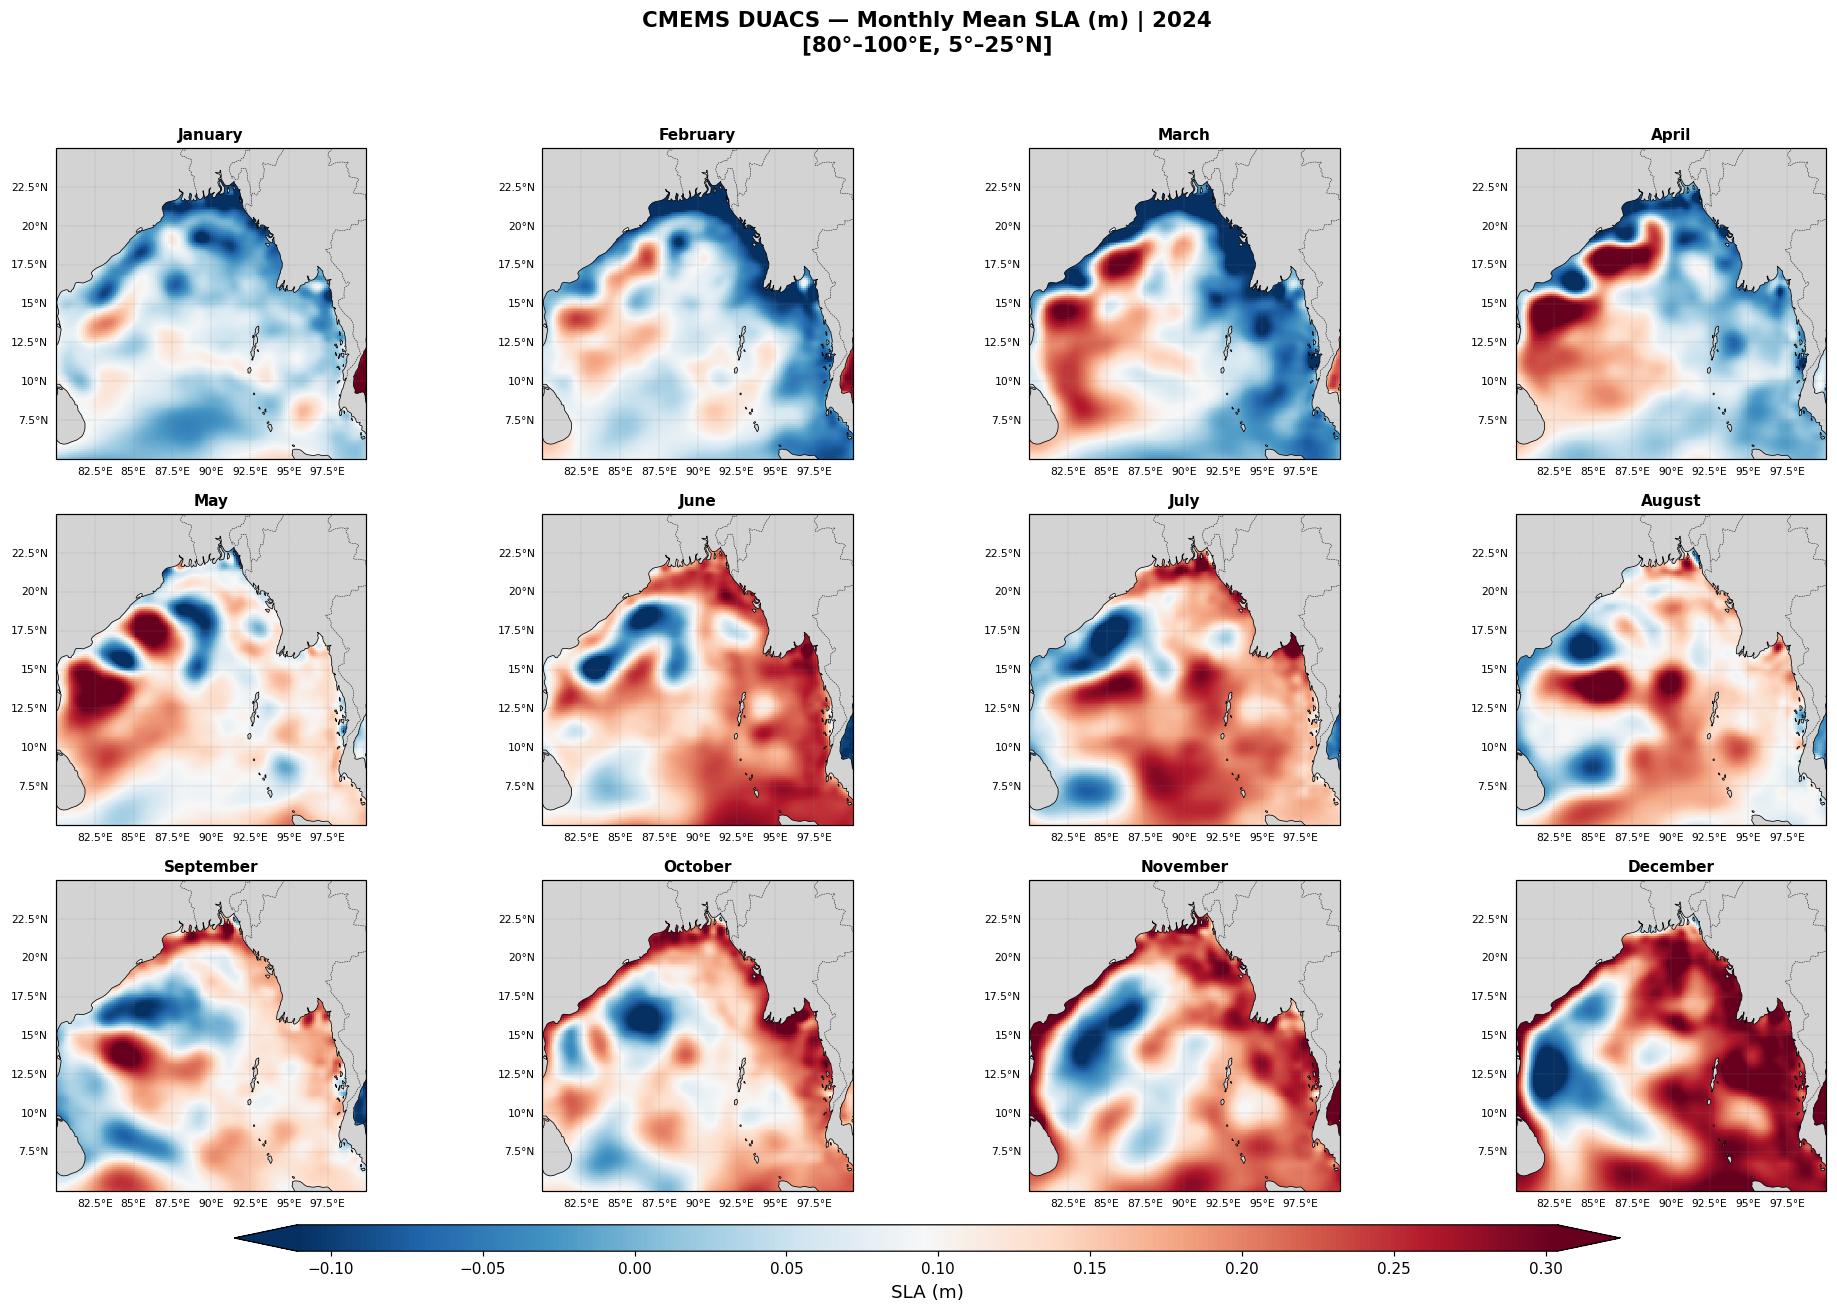

In [45]:
if DO_MONTHLY:
    monthly_outputs = []
    for yr in YEARS:
        path = create_monthly_mean_maps(
            all_files=all_files,
            year=yr,
            output_dir=OUTPUT_DIR,
            var_name=VAR_NAME,
            region=REGION,
            region_label=REGION_LABEL,
            vmin=SLA_VMIN,
            vmax=SLA_VMAX,
            cmap=SLA_CMAP,
        )
        if path:
            monthly_outputs.append(path)
else:
    print("DO_MONTHLY = False \u2014 skipping monthly mean maps.")
    monthly_outputs = []

---
## Section 6 — Monthly Anomaly Maps

Produces one 3\u00d74 panel figure per year in `YEARS`.  Each panel shows
monthly anomaly = monthly\_mean \u2212 annual\_mean, using a symmetric diverging
colorbar so positive and negative departures are directly comparable.

**Output filename:** `<VAR>_Monthly_Anomaly_<YEAR>.png`

In [46]:
def create_anomaly_maps(all_files, year, output_dir, var_name,
                         region, region_label, cmap):
    """
    Build and save a 3\u00d74 panel of monthly anomaly maps for one calendar year.

    **Anomaly definition:** monthly\_mean \u2212 annual\_mean, where the annual
    mean is the pixel-wise mean of all 12 monthly-mean arrays.  This reveals
    seasonal departures from the year-round average.

    Workflow
    --------
    1. Loads all 12 monthly means using the same file-by-file approach as
       ``create_monthly_mean_maps``
       (``load_cmems_var`` \u2192 ``xr.concat`` \u2192 ``.mean``).
    2. Computes the annual mean as the pixel-wise mean of the 12 monthly arrays.
    3. Subtracts the annual mean from each monthly mean.
    4. Sets a symmetric colorbar at \u00b198th percentile of ``|anomaly|`` so the
       zero-anomaly midpoint aligns with the colormap centre.

    Parameters
    ----------
    all_files : list of str
        Complete sorted file list returned by ``scan_cmems_dataset``.
    year : int
        Calendar year to process (e.g. ``2024``).
    output_dir : str
        Directory where the PNG is saved.  Created automatically if absent.
    var_name : str
        CMEMS variable name (e.g. ``"sla"``, ``"adt"``).
    region : list of float or None
        ``[lon_min, lon_max, lat_min, lat_max]`` or ``None`` for global.
    region_label : str
        Human-readable region string used in the figure super-title.
    cmap : str
        Diverging colormap name (e.g. ``"RdBu_r"``).

    Returns
    -------
    str or None
        Absolute path to the saved PNG, or ``None`` if insufficient data
        (fewer than 2 months loaded).
    """
    print(f"\n{'='*65}")
    print(f"Monthly anomaly maps \u2014 {var_name.upper()} \u2014 {year}")
    print("=" * 65)

    os.makedirs(output_dir, exist_ok=True)

    # Load monthly means (same approach as create_monthly_mean_maps)
    monthly_means = {}
    for month_idx in range(12):
        month_num = month_idx + 1
        print(f"  {month_name[month_num]:>12} {year} \u2026 ", end="", flush=True)

        month_files = get_files_for_month(all_files, year, month_num)
        if not month_files:
            print("no data")
            continue

        daily_list = []
        for day, filepath in sorted(month_files.items()):
            try:
                daily_list.append(load_cmems_var(filepath, var_name, region))
            except Exception as e:
                print(f"\n    Warning \u2014 day {day}: {e}", end="")

        if daily_list:
            monthly_means[month_num] = xr.concat(daily_list, dim='day').mean(dim='day')
            print(f"done ({len(daily_list)} days)")
        else:
            print("load error")

    if len(monthly_means) < 2:
        print("  Insufficient data for anomaly computation.")
        return None

    # Annual mean and per-month anomalies
    annual_mean = xr.concat(list(monthly_means.values()), dim='month').mean(dim='month')
    anomalies   = {m: da - annual_mean for m, da in monthly_means.items()}

    # Symmetric colour limits
    vabs = float(np.abs(
        xr.concat(list(anomalies.values()), dim='month')
    ).quantile(0.98))

    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    img_handle = None

    for i in range(12):
        m = i + 1
        ax = axes[i]
        if m in anomalies:
            img_handle = make_sla_map(ax, anomalies[m], month_name[m],
                                       -vabs, vabs, cmap)
            if region is not None:
                ax.set_extent(region, crs=ccrs.PlateCarree())
        else:
            ax.set_title(f"{month_name[m]} (no data)", fontsize=10)
            ax.axis('off')

    if img_handle is not None:
        cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
        cbar = fig.colorbar(img_handle, cax=cbar_ax,
                            orientation='horizontal', extend='both')
        cbar.set_label(f'{var_name.upper()} anomaly (m)', fontsize=12)

    fig.suptitle(
        f"CMEMS DUACS \u2014 {var_name.upper()} Monthly Anomaly (vs Annual Mean) "
        f"| {year}\n{region_label}",
        fontsize=14, fontweight='bold', y=0.98
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])

    out_path = os.path.join(output_dir, f"{var_name.upper()}_Monthly_Anomaly_{year}.png")
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    fig.show()
    print(f"\n  Saved \u2192 {out_path}")
    return out_path


Monthly anomaly maps — SLA — 2024
       January 2024 … done (31 days)
      February 2024 … done (29 days)
         March 2024 … done (31 days)
         April 2024 … done (30 days)
           May 2024 … done (31 days)
          June 2024 … done (30 days)
          July 2024 … done (31 days)
        August 2024 … done (31 days)
     September 2024 … done (30 days)
       October 2024 … done (31 days)
      November 2024 … done (30 days)
      December 2024 … done (31 days)

  Saved → C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs\SLA_Monthly_Anomaly_2024.png


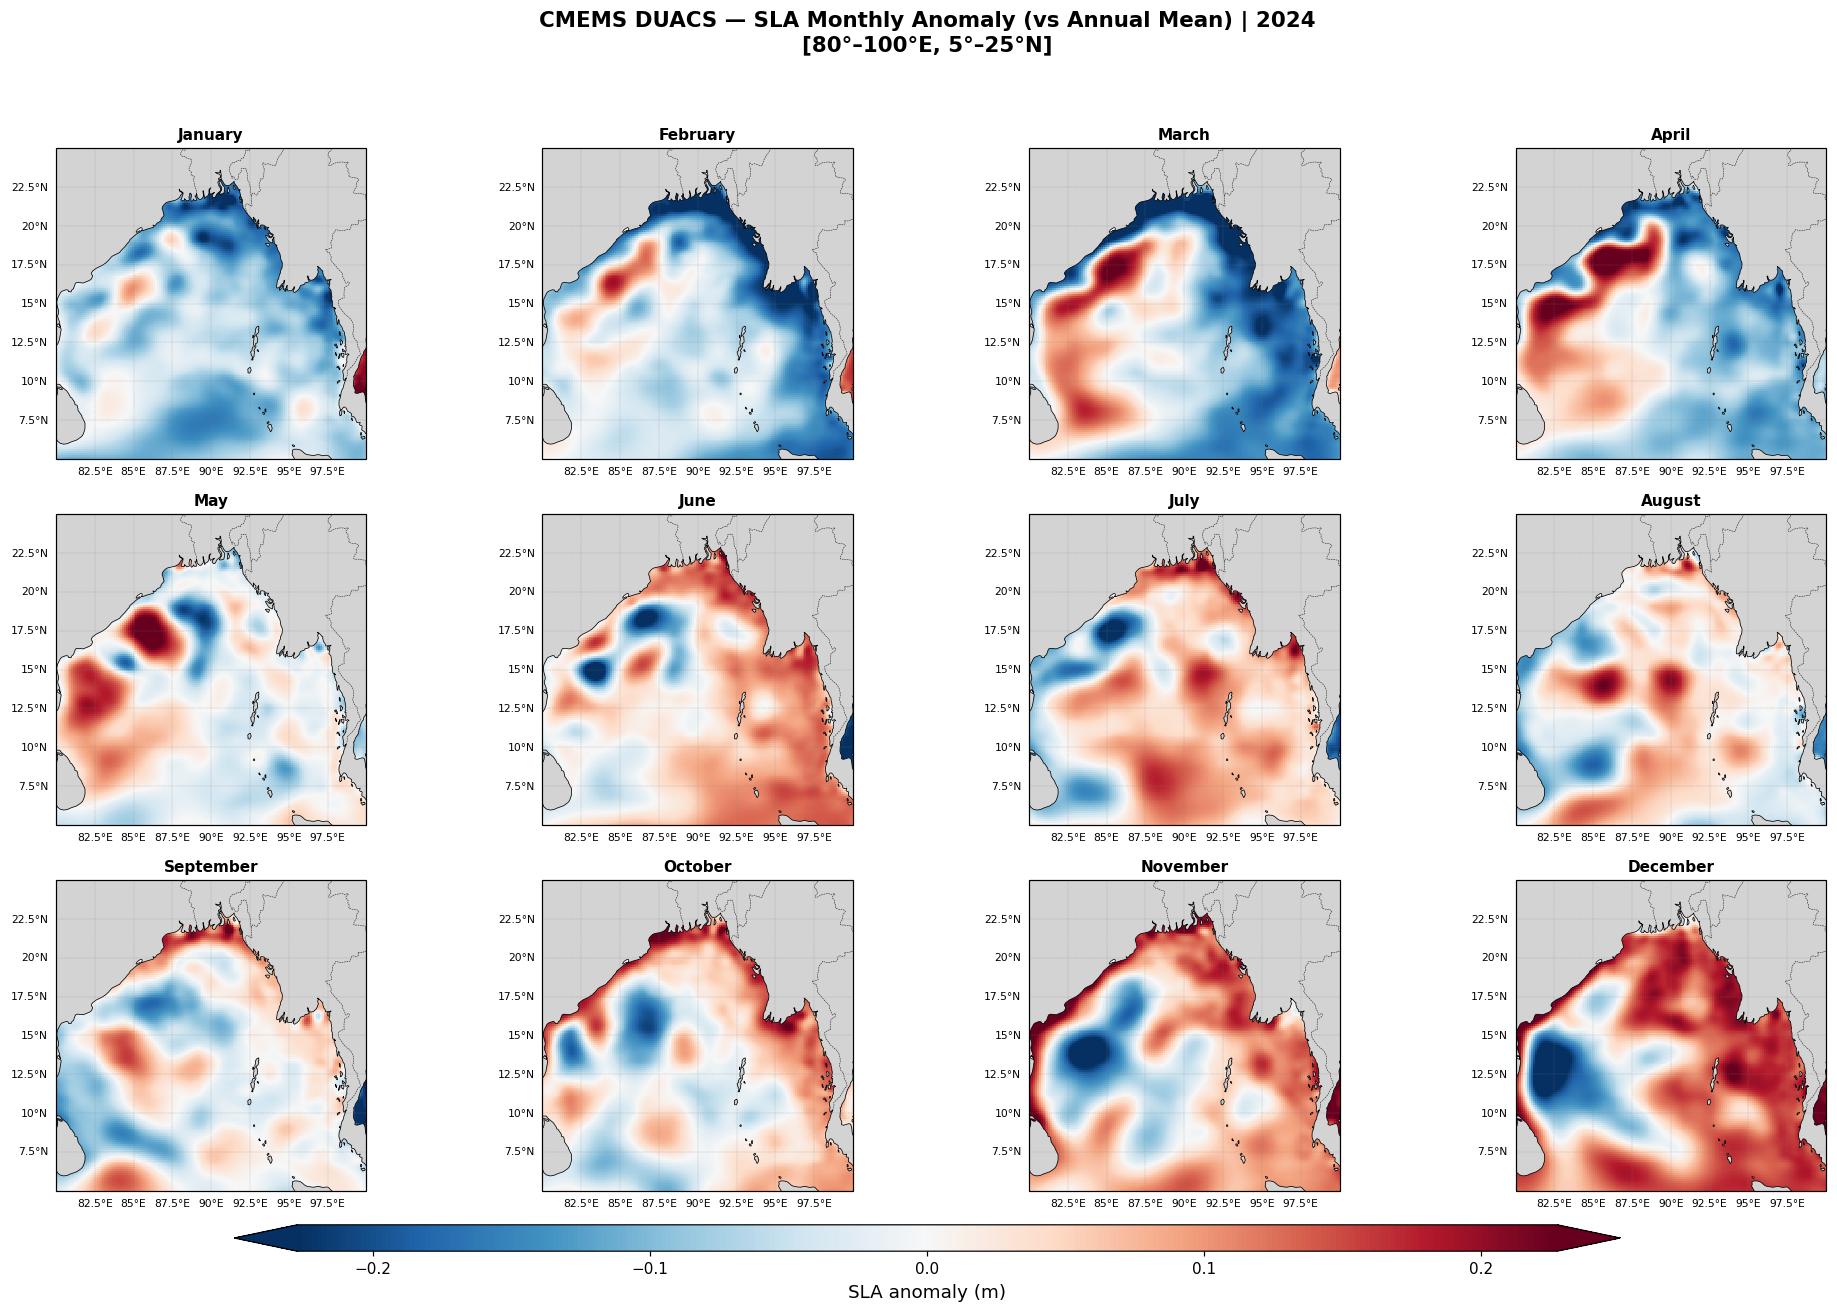

In [47]:
if DO_ANOMALY:
    anomaly_outputs = []
    for yr in YEARS:
        path = create_anomaly_maps(
            all_files=all_files,
            year=yr,
            output_dir=OUTPUT_DIR,
            var_name=VAR_NAME,
            region=REGION,
            region_label=REGION_LABEL,
            cmap=SLA_CMAP,
        )
        if path:
            anomaly_outputs.append(path)
else:
    print("DO_ANOMALY = False \u2014 skipping anomaly maps.")
    anomaly_outputs = []

---
## Section 7 — Daily Maps

Produces one panel figure per year in `YEARS`, showing daily maps for
the month and day range set in the Configuration cell.

**Output filename:** `<VAR>_Daily_<YEAR>_<MM>_Day<start>-<end>.png`

In [48]:
def create_daily_maps(all_files, year, month, day_start, day_end, days_per_row,
                      output_dir, var_name, region, region_label, vmin, vmax, cmap):
    """
    Build and save a panel figure showing daily maps for a date range.

    Loads one DataArray per requested calendar day and tiles the maps in a
    grid with *days_per_row* columns.  Days for which no file exists in the
    dataset (e.g. data gaps) are silently omitted from the panel.  Days that
    fail to load are rendered as blank subplots with an error label.

    When *vmin* and *vmax* are both ``None``, colour limits are auto-computed
    from the 2nd and 98th percentile across all loaded days so that the
    colorbar is consistent across the entire panel.

    A shared horizontal colorbar is drawn below the full panel grid.
    Unused subplot slots (when the number of plotted days is not a multiple
    of *days_per_row*) are hidden with ``axis('off')``.

    Parameters
    ----------
    all_files : list of str
        Complete sorted file list returned by ``scan_cmems_dataset``.
    year : int
        Calendar year (e.g. ``2024``).
    month : int
        Month number 1\u201312.
    day_start : int
        First day of the range to plot (inclusive).
    day_end : int
        Last day of the range to plot (inclusive).
    days_per_row : int
        Number of subplot columns.  More columns produce a wider figure.
    output_dir : str
        Directory where the PNG is saved.  Created automatically if absent.
    var_name : str
        CMEMS variable name (e.g. ``"sla"``, ``"adt"``).
    region : list of float or None
        ``[lon_min, lon_max, lat_min, lat_max]`` or ``None`` for global.
    region_label : str
        Human-readable region string used in the figure super-title.
    vmin, vmax : float or None
        Colorbar limits in metres.  ``None`` triggers auto-scaling.
    cmap : str
        Matplotlib colormap name.

    Returns
    -------
    str or None
        Absolute path to the saved PNG, or ``None`` if no data files were
        found for the requested month and day range.
    """
    print(f"\n{'='*65}")
    print(f"Daily maps \u2014 {var_name.upper()} \u2014 "
          f"{month_name[month]} {year}, days {day_start}\u2013{day_end}")
    print("=" * 65)

    os.makedirs(output_dir, exist_ok=True)

    month_files = get_files_for_month(all_files, year, month)
    days_to_plot = [
        (d, month_files[d])
        for d in range(day_start, day_end + 1)
        if d in month_files
    ]

    if not days_to_plot:
        print(f"  No data files for {month_name[month]} {year} "
              f"days {day_start}\u2013{day_end}.")
        return None

    print(f"  Loading {len(days_to_plot)} day(s) \u2026")

    # Phase 1: load all days
    daily_data = {}
    for day, filepath in days_to_plot:
        date_str = f"{year}-{month:02d}-{day:02d}"
        print(f"    {date_str} \u2026 ", end="", flush=True)
        try:
            daily_data[day] = load_cmems_var(filepath, var_name, region)
            print("done")
        except Exception as e:
            print(f"error: {e}")

    if not daily_data:
        return None

    # Resolve colour limits
    _vmin, _vmax = vmin, vmax
    if _vmin is None or _vmax is None:
        stack = xr.concat(list(daily_data.values()), dim='day')
        if _vmin is None:
            _vmin = float(stack.quantile(0.02))
        if _vmax is None:
            _vmax = float(stack.quantile(0.98))

    ncols = min(days_per_row, len(daily_data))
    nrows = ceil(len(daily_data) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4 * ncols, 3.5 * nrows + 1),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    axes_flat  = axes.flatten()
    img_handle = None

    # Phase 2: plot
    for idx, (day, da) in enumerate(sorted(daily_data.items())):
        ax = axes_flat[idx]
        date_str = f"{year}-{month:02d}-{day:02d}"
        try:
            img_handle = make_sla_map(ax, da, date_str, _vmin, _vmax, cmap)
            if region is not None:
                ax.set_extent(region, crs=ccrs.PlateCarree())
        except Exception as e:
            ax.set_title(f"{date_str}\n(error)", fontsize=9)
            ax.axis('off')

    for idx in range(len(daily_data), len(axes_flat)):
        axes_flat[idx].axis('off')

    if img_handle is not None:
        cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.015])
        cbar = fig.colorbar(img_handle, cax=cbar_ax,
                            orientation='horizontal', extend='both')
        cbar.set_label(f'{var_name.upper()} (m)', fontsize=11)

    fig.suptitle(
        f"CMEMS DUACS \u2014 Daily {var_name.upper()} (m) | "
        f"{month_name[month]} {year} (Day {day_start}\u2013{day_end})"
        f"\n{region_label}",
        fontsize=13, fontweight='bold', y=0.98
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])

    fname = (f"{var_name.upper()}_Daily_{year}_{month:02d}"
             f"_Day{day_start:02d}-{day_end:02d}.png")
    out_path = os.path.join(output_dir, fname)
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    fig.show()
    print(f"\n  Saved \u2192 {out_path}")
    return out_path


Daily maps — SLA — January 2024, days 1–7
  Loading 7 day(s) …
    2024-01-01 … done
    2024-01-02 … done
    2024-01-03 … done
    2024-01-04 … done
    2024-01-05 … done
    2024-01-06 … done
    2024-01-07 … done

  Saved → C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs\SLA_Daily_2024_01_Day01-07.png


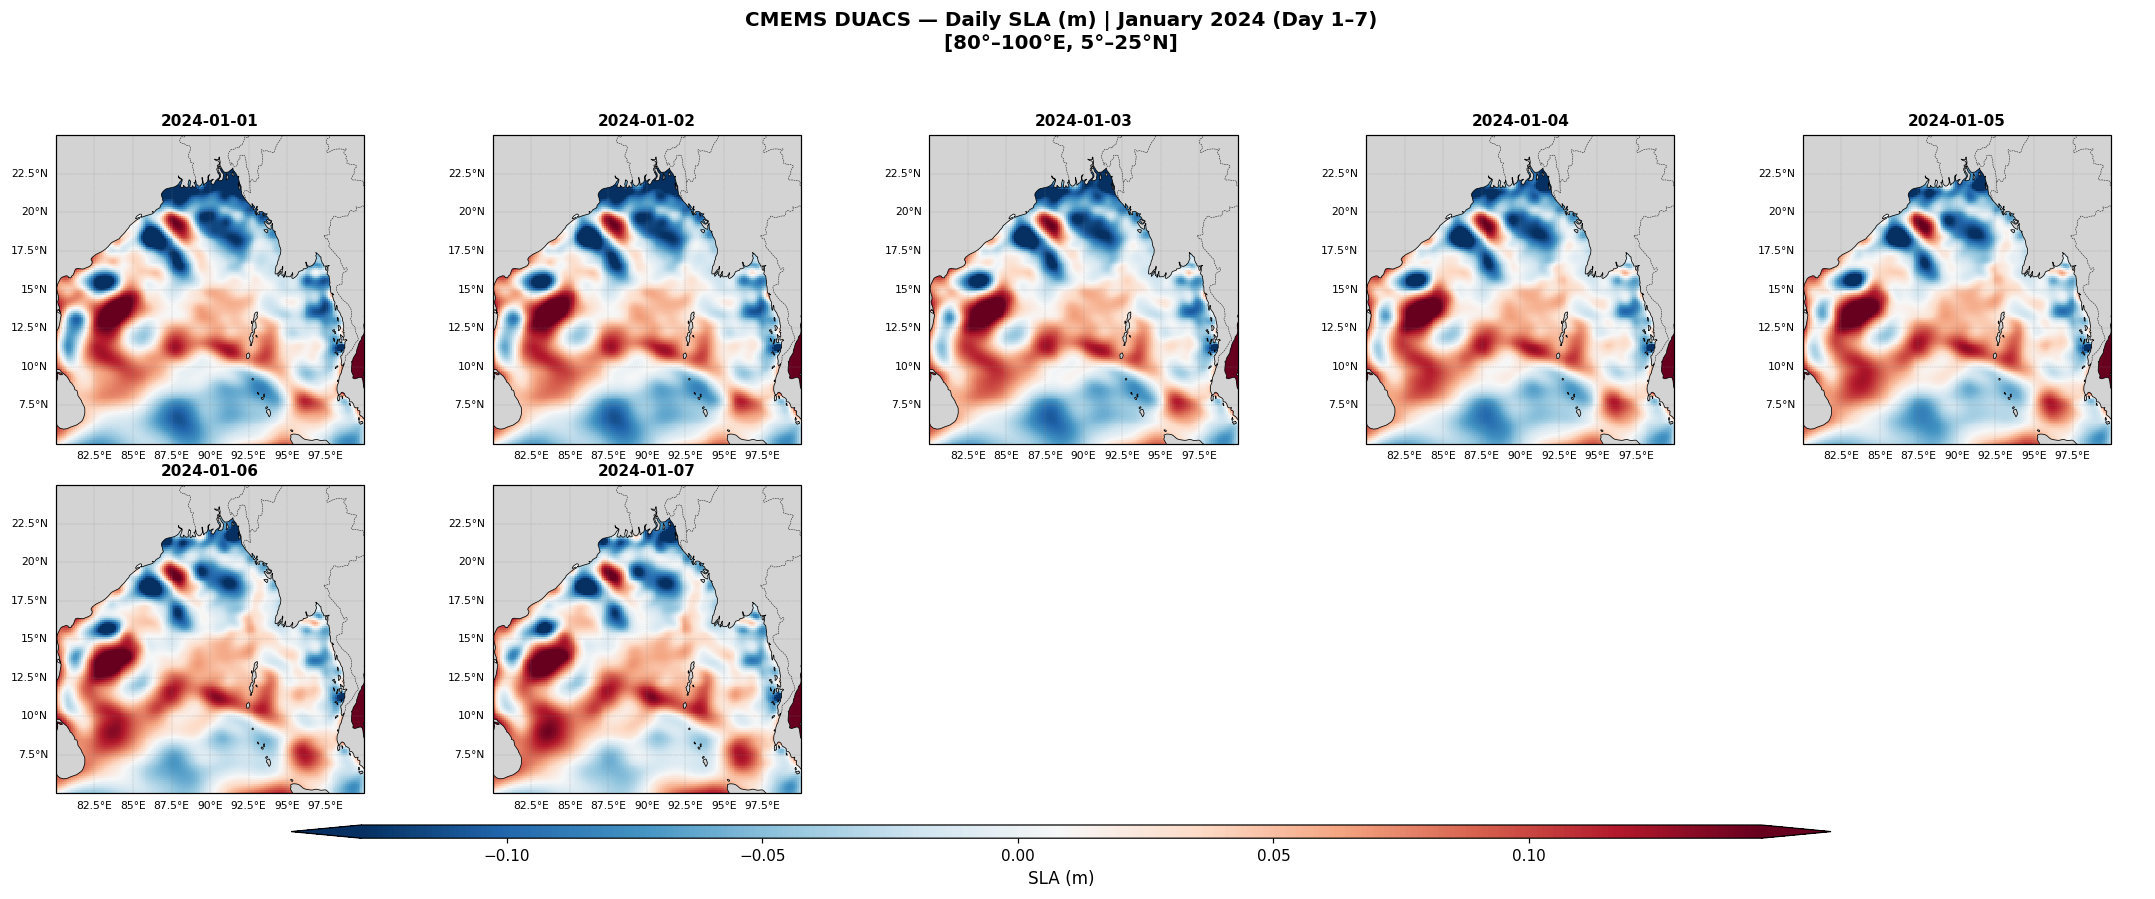

In [49]:
if DO_DAILY:
    daily_outputs = []
    for yr in YEARS:
        path = create_daily_maps(
            all_files=all_files,
            year=yr,
            month=DAILY_MONTH,
            day_start=DAILY_DAY_START,
            day_end=DAILY_DAY_END,
            days_per_row=DAYS_PER_ROW,
            output_dir=OUTPUT_DIR,
            var_name=VAR_NAME,
            region=REGION,
            region_label=REGION_LABEL,
            vmin=SLA_VMIN,
            vmax=SLA_VMAX,
            cmap=SLA_CMAP,
        )
        if path:
            daily_outputs.append(path)
else:
    print("DO_DAILY = False \u2014 skipping daily maps.")
    daily_outputs = []

---
## Section 8 — Summary

In [50]:
print("=" * 65)
print("RUN COMPLETE \u2014 output files")
print("=" * 65)

all_outputs = monthly_outputs + anomaly_outputs + daily_outputs

if all_outputs:
    for p in all_outputs:
        print(f"  {p}")
else:
    print("  (no output files \u2014 check DO_MONTHLY / DO_ANOMALY / DO_DAILY "
          "in Configuration)")

print(f"\n  Total .nc files in dataset : {len(all_files)}")
print(f"  Years processed            : {YEARS}")
print(f"  Variable                   : {VAR_NAME}")
print(f"  Region                     : {REGION_LABEL}")

RUN COMPLETE — output files
  C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs\SLA_Monthly_Mean_2024.png
  C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs\SLA_Monthly_Anomaly_2024.png
  C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024\outputs\SLA_Daily_2024_01_Day01-07.png

  Total .nc files in dataset : 366
  Years processed            : [2024]
  Variable                   : sla
  Region                     : [80°–100°E, 5°–25°N]
